In [3]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [4]:
from pyexpat import model
load_dotenv()
from langchain_ollama import ChatOllama
model = ChatOllama(
    model="qwen3:4b",
    temperature=0,
    think=False
)

In [5]:
class ChatState(MessagesState):
    summary: str

In [6]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [7]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [8]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [9]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [10]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

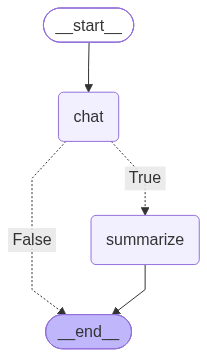

In [11]:
graph

In [12]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [13]:

# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [14]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='57b587d1-3544-498a-b2ee-c7ea96ab665b')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics (or **quantum mechanics**) is the branch of physics that describ


In [15]:

run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='57b587d1-3544-498a-b2ee-c7ea96ab665b'), AIMessage(content='Quantum physics (or **quantum mechanics**) is the branch of physics that describes the behavior of matter and energy at the **smallest scales**—atoms, subatomic particles (electrons, protons, quarks), and even smaller entities like photons. It\'s the foundation of modern technology (e.g., semiconductors, lasers, MRI machines) and reshapes our understanding of reality. Below is a clear, structured overview designed for **anyone**—no prior knowledge needed.\n\n---\n\n### 🔑 **Why Quantum Physics Matters**\n- **Real-world impact**: Without quantum physics, there would be no smartphones, computers, medical imaging, or modern chemistry.  \n- **Fundamental reality**: It explains *why* atoms don’t collapse, how light interacts with matter, and even the behavior of stars.  \n- **Mind-bending**: It contradicts everyday intuition (e.g., "objects have 

In [16]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='57b587d1-3544-498a-b2ee-c7ea96ab665b'), AIMessage(content='Quantum physics (or **quantum mechanics**) is the branch of physics that describes the behavior of matter and energy at the **smallest scales**—atoms, subatomic particles (electrons, protons, quarks), and even smaller entities like photons. It\'s the foundation of modern technology (e.g., semiconductors, lasers, MRI machines) and reshapes our understanding of reality. Below is a clear, structured overview designed for **anyone**—no prior knowledge needed.\n\n---\n\n### 🔑 **Why Quantum Physics Matters**\n- **Real-world impact**: Without quantum physics, there would be no smartphones, computers, medical imaging, or modern chemistry.  \n- **Fundamental reality**: It explains *why* atoms don’t collapse, how light interacts with matter, and even the behavior of stars.  \n- **Mind-bending**: It contradicts everyday intuition (e.g., "objects have 

In [17]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='57b587d1-3544-498a-b2ee-c7ea96ab665b'), AIMessage(content='Quantum physics (or **quantum mechanics**) is the branch of physics that describes the behavior of matter and energy at the **smallest scales**—atoms, subatomic particles (electrons, protons, quarks), and even smaller entities like photons. It\'s the foundation of modern technology (e.g., semiconductors, lasers, MRI machines) and reshapes our understanding of reality. Below is a clear, structured overview designed for **anyone**—no prior knowledge needed.\n\n---\n\n### 🔑 **Why Quantum Physics Matters**\n- **Real-world impact**: Without quantum physics, there would be no smartphones, computers, medical imaging, or modern chemistry.  \n- **Fundamental reality**: It explains *why* atoms don’t collapse, how light interacts with matter, and even the behavior of stars.  \n- **Mind-bending**: It contradicts everyday intuition (e.g., "objects have 